In [24]:
import pandas as pd
from utils.ml_utils_v2 import EnsembleProjections
import os
import joblib

In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
ep = EnsembleProjections()

In [27]:
# Set up paths
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
RESULTS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "results")
OUTPUT_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "output")
ENSEMBLE_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "ensemble")
MODELS_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "models")
TRAINING_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "training")

In [28]:
# Ensemble params
n_scenarios = 10

# Load data
training_df_log_transformed = pd.read_csv(os.path.join(TRAINING_DIR_PATH, "training_df_log_transformed.csv"))
training_df_lags = pd.read_csv(os.path.join(TRAINING_DIR_PATH, "training_df_lags.csv"))
ensemble_arima_df = pd.read_csv(os.path.join(ENSEMBLE_DIR_PATH, f"ensemble_arima_{n_scenarios}_df.csv"))

In [29]:
# Print shapes
print(f"Training df log transformed shape: {training_df_log_transformed.shape}")
print(f"Training df lags shape: {training_df_lags.shape}")
print(f"Ensemble ARIMA df shape: {ensemble_arima_df.shape}") 

Training df log transformed shape: (3652, 19)
Training df lags shape: (3652, 19)
Ensemble ARIMA df shape: (14940, 17)


In [30]:
# Get the models from the models directory with keys without .pkl extension
models = {}
for model_name in os.listdir(MODELS_DIR_PATH):
    if model_name.endswith(".pkl"):
        model_path = os.path.join(MODELS_DIR_PATH, model_name)
        key_name = model_name[:-4]  # remove .pkl extension
        models[key_name] = joblib.load(model_path)

models.keys()

dict_keys(['reg_with_isos_enet_pipeline', 'reg_with_isos_xgb_pipeline', 'reg_no_isos_xgb_pipeline', 'reg_no_isos_enet_pipeline'])

In [31]:
# Get a df with only iso_alpha_3, income_group and region cols
iso_alpha_3_cols = ["iso_alpha_3", "income_group", "region"]
income_group_region_mapping_df = training_df_log_transformed[iso_alpha_3_cols].drop_duplicates().reset_index(drop=True)
income_group_region_mapping_df.head()

,iso_alpha_3,income_group,region
0,ABW,High income,Latin America & Caribbean
1,AFG,Low income,South Asia
2,AGO,Lower middle income,Africa Eastern and Southern
3,ALB,Upper middle income,Europe & Central Asia
4,ARE,High income,Middle East & North Africa


In [44]:
initial_conditions_df = training_df_lags[training_df_lags["year"] == 2022].copy()
initial_conditions_df = initial_conditions_df.reset_index(drop=True)
initial_conditions_df = initial_conditions_df[["iso_alpha_3", "year", "total_emissions"]]
initial_conditions_df

,iso_alpha_3,year,total_emissions
0,ABW,2022,0.496683
1,AFG,2022,38.457458
2,AGO,2022,136.889648
3,ALB,2022,9.252882
4,ARE,2022,286.675891
...,...,...,...
161,VNM,2022,449.692567
162,YEM,2022,36.119043
163,ZAF,2022,503.193706
164,ZMB,2022,77.421588


In [32]:
ensemble_arima_df.head()

,iso_alpha_3,future_id,year,renewable_energy_consumption_pct,forest_area_pct,log_pop_total,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,log_exports_2015_usd,log_gdp_2015_usd_lag1,log_imports_2015_usd_lag1,log_exports_2015_usd_lag1,log_industry_value_added_2015_usd_lag1,log_manufacturing_value_added_2015_usd_lag1,log_pop_total_lag1
0,ABW,id_ABW_1,2022,7.052790,2.333333,11.577592,21.734613,21.494463,19.727497,18.481103,21.492707,21.884877,21.494462,21.492710,19.727498,18.481105,11.580003
1,ABW,id_ABW_2,2022,8.147565,2.333334,11.583839,21.762643,21.494463,19.727498,18.481105,21.492710,21.775629,21.494463,21.492709,19.727498,18.481102,11.575524
2,ABW,id_ABW_3,2022,8.057343,2.333334,11.579244,21.819856,21.494462,19.727499,18.481104,21.492707,21.873571,21.494462,21.492710,19.727499,18.481104,11.583500
3,ABW,id_ABW_4,2022,8.981733,2.333334,11.584768,21.715132,21.494463,19.727497,18.481102,21.492710,21.899219,21.494463,21.492708,19.727500,18.481104,11.585799
4,ABW,id_ABW_5,2022,8.666764,2.333331,11.586537,21.925924,21.494463,19.727498,18.481102,21.492708,21.867987,21.494461,21.492709,19.727498,18.481103,11.584784


In [33]:
# Merge the income group and region mapping df with the ensemble df
ensemble_arima_df = pd.merge(ensemble_arima_df, income_group_region_mapping_df,
                             on="iso_alpha_3", how="left")

ensemble_arima_df.head()

,iso_alpha_3,future_id,year,renewable_energy_consumption_pct,forest_area_pct,log_pop_total,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,log_exports_2015_usd,log_gdp_2015_usd_lag1,log_imports_2015_usd_lag1,log_exports_2015_usd_lag1,log_industry_value_added_2015_usd_lag1,log_manufacturing_value_added_2015_usd_lag1,log_pop_total_lag1,income_group,region
0,ABW,id_ABW_1,2022,7.052790,2.333333,11.577592,21.734613,21.494463,19.727497,18.481103,21.492707,21.884877,21.494462,21.492710,19.727498,18.481105,11.580003,High income,Latin America & Caribbean
1,ABW,id_ABW_2,2022,8.147565,2.333334,11.583839,21.762643,21.494463,19.727498,18.481105,21.492710,21.775629,21.494463,21.492709,19.727498,18.481102,11.575524,High income,Latin America & Caribbean
2,ABW,id_ABW_3,2022,8.057343,2.333334,11.579244,21.819856,21.494462,19.727499,18.481104,21.492707,21.873571,21.494462,21.492710,19.727499,18.481104,11.583500,High income,Latin America & Caribbean
3,ABW,id_ABW_4,2022,8.981733,2.333334,11.584768,21.715132,21.494463,19.727497,18.481102,21.492710,21.899219,21.494463,21.492708,19.727500,18.481104,11.585799,High income,Latin America & Caribbean
4,ABW,id_ABW_5,2022,8.666764,2.333331,11.586537,21.925924,21.494463,19.727498,18.481102,21.492708,21.867987,21.494461,21.492709,19.727498,18.481103,11.584784,High income,Latin America & Caribbean


## Let's check the feature variables projections

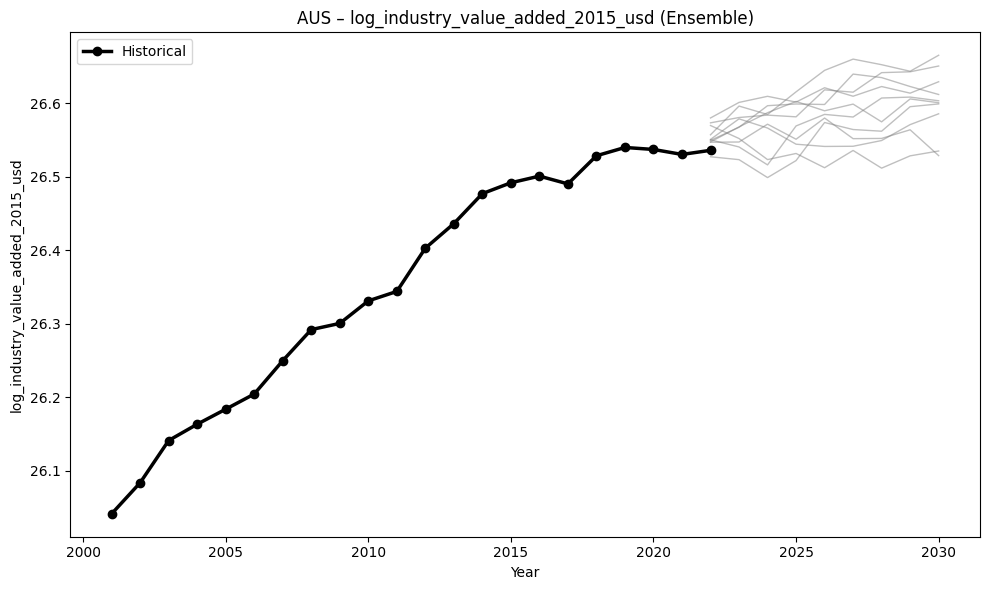

In [49]:
ep.plot_ensemble_time_series(
    df=ensemble_arima_df, 
    iso_alpha_3="AUS",
    column="log_industry_value_added_2015_usd",
    hist_df=training_df_log_transformed)

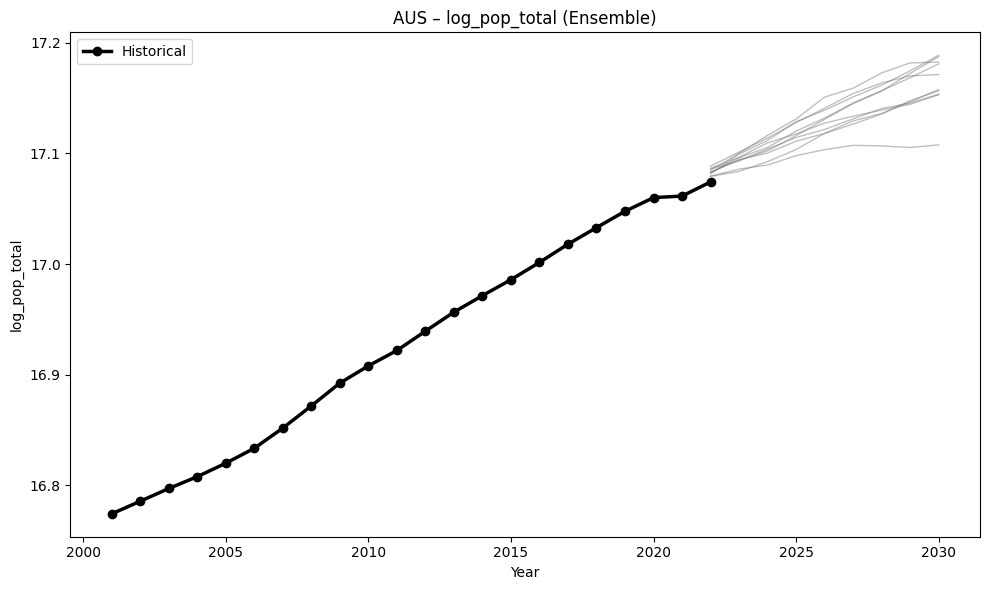

In [50]:
ep.plot_ensemble_time_series(
    df=ensemble_arima_df, 
    iso_alpha_3="AUS",
    column="log_pop_total",
    hist_df=training_df_log_transformed)

## Let's do a prediction and see how it looks without rescaling

In [36]:
# Get feature cols
feature_cols_no_isos = [c for c in  training_df_log_transformed.columns if c not in ["iso_alpha_3", "log_total_emissions"]]
feature_cols_no_isos

['income_group',
 'region',
 'year',
 'renewable_energy_consumption_pct',
 'forest_area_pct',
 'log_pop_total',
 'log_gdp_2015_usd',
 'log_imports_2015_usd',
 'log_industry_value_added_2015_usd',
 'log_manufacturing_value_added_2015_usd',
 'log_exports_2015_usd',
 'log_gdp_2015_usd_lag1',
 'log_imports_2015_usd_lag1',
 'log_exports_2015_usd_lag1',
 'log_industry_value_added_2015_usd_lag1',
 'log_manufacturing_value_added_2015_usd_lag1',
 'log_pop_total_lag1']

In [39]:
feature_cols_with_isos = [c for c in training_df_log_transformed.columns if c not in ["log_total_emissions"]]
feature_cols_with_isos

['iso_alpha_3',
 'income_group',
 'region',
 'year',
 'renewable_energy_consumption_pct',
 'forest_area_pct',
 'log_pop_total',
 'log_gdp_2015_usd',
 'log_imports_2015_usd',
 'log_industry_value_added_2015_usd',
 'log_manufacturing_value_added_2015_usd',
 'log_exports_2015_usd',
 'log_gdp_2015_usd_lag1',
 'log_imports_2015_usd_lag1',
 'log_exports_2015_usd_lag1',
 'log_industry_value_added_2015_usd_lag1',
 'log_manufacturing_value_added_2015_usd_lag1',
 'log_pop_total_lag1']

In [37]:
xgb_no_isos_df = ep.predict_ensemble_emissions(ensemble_arima_df, models["reg_no_isos_xgb_pipeline"], feature_cols=feature_cols_no_isos)
xgb_no_isos_df.head()

,iso_alpha_3,future_id,year,renewable_energy_consumption_pct,forest_area_pct,log_pop_total,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,...,log_gdp_2015_usd_lag1,log_imports_2015_usd_lag1,log_exports_2015_usd_lag1,log_industry_value_added_2015_usd_lag1,log_manufacturing_value_added_2015_usd_lag1,log_pop_total_lag1,income_group,region,log_total_emissions,total_emissions
0,ABW,id_ABW_1,2022,7.052790,2.333333,11.577592,21.734613,21.494463,19.727497,18.481103,...,21.884877,21.494462,21.492710,19.727498,18.481105,11.580003,High income,Latin America & Caribbean,0.343881,1.410411
1,ABW,id_ABW_2,2022,8.147565,2.333334,11.583839,21.762643,21.494463,19.727498,18.481105,...,21.775629,21.494463,21.492709,19.727498,18.481102,11.575524,High income,Latin America & Caribbean,0.337802,1.401864
2,ABW,id_ABW_3,2022,8.057343,2.333334,11.579244,21.819856,21.494462,19.727499,18.481104,...,21.873571,21.494462,21.492710,19.727499,18.481104,11.583500,High income,Latin America & Caribbean,0.337802,1.401864
3,ABW,id_ABW_4,2022,8.981733,2.333334,11.584768,21.715132,21.494463,19.727497,18.481102,...,21.899219,21.494463,21.492708,19.727500,18.481104,11.585799,High income,Latin America & Caribbean,0.327157,1.387019
4,ABW,id_ABW_5,2022,8.666764,2.333331,11.586537,21.925924,21.494463,19.727498,18.481102,...,21.867987,21.494461,21.492709,19.727498,18.481103,11.584784,High income,Latin America & Caribbean,0.327157,1.387019


In [40]:
enet_no_isos_df = ep.predict_ensemble_emissions(ensemble_arima_df, models["reg_no_isos_enet_pipeline"], feature_cols=feature_cols_no_isos)
xgb_with_isos_df = ep.predict_ensemble_emissions(ensemble_arima_df, models["reg_with_isos_xgb_pipeline"], feature_cols=feature_cols_with_isos)
enet_with_isos_df = ep.predict_ensemble_emissions(ensemble_arima_df, models["reg_with_isos_enet_pipeline"], feature_cols=feature_cols_with_isos)

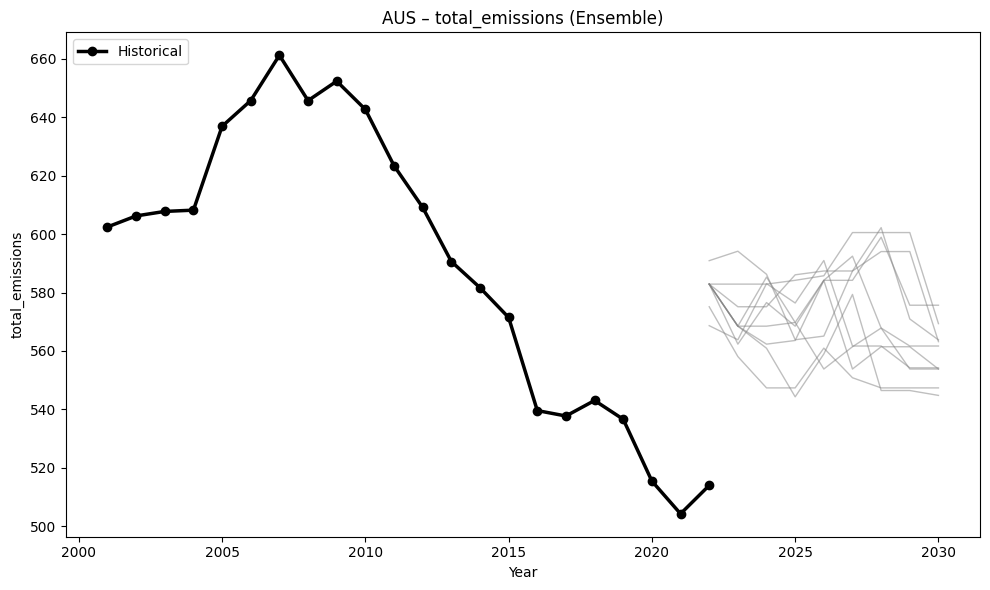

In [51]:
ep.plot_ensemble_time_series(
    df=xgb_no_isos_df, 
    iso_alpha_3="AUS",
    column="total_emissions",
    hist_df=training_df_lags)

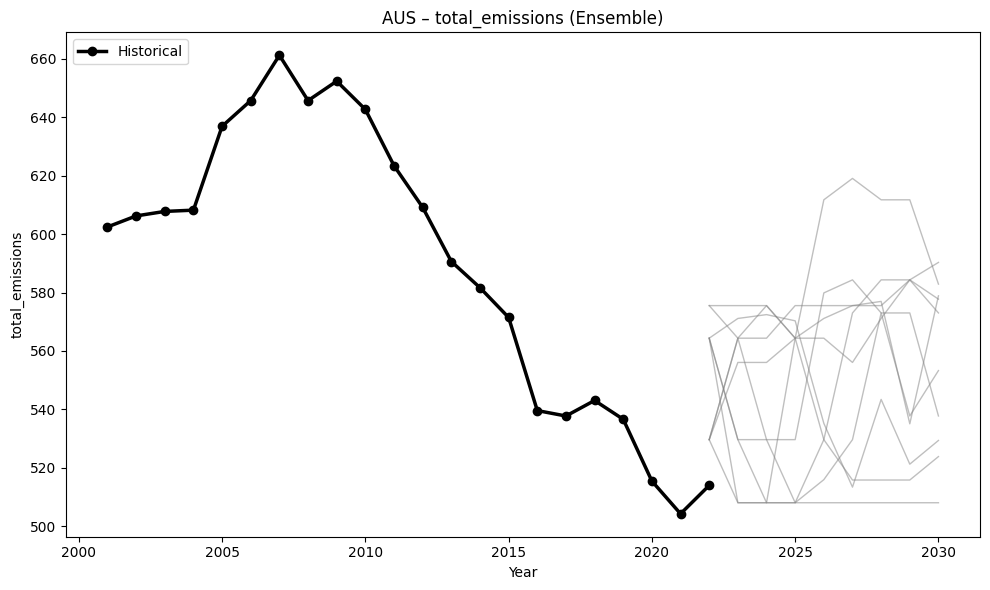

In [52]:
ep.plot_ensemble_time_series(
    df=xgb_with_isos_df, 
    iso_alpha_3="AUS",
    column="total_emissions",
    hist_df=training_df_lags)

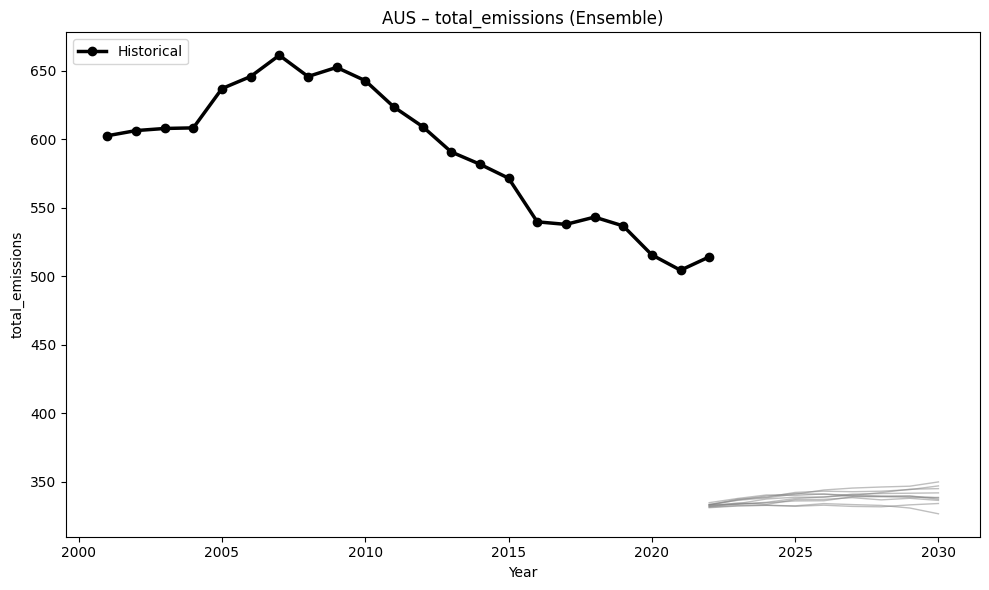

In [53]:
ep.plot_ensemble_time_series(
    df=enet_no_isos_df, 
    iso_alpha_3="AUS",
    column="total_emissions",
    hist_df=training_df_lags)

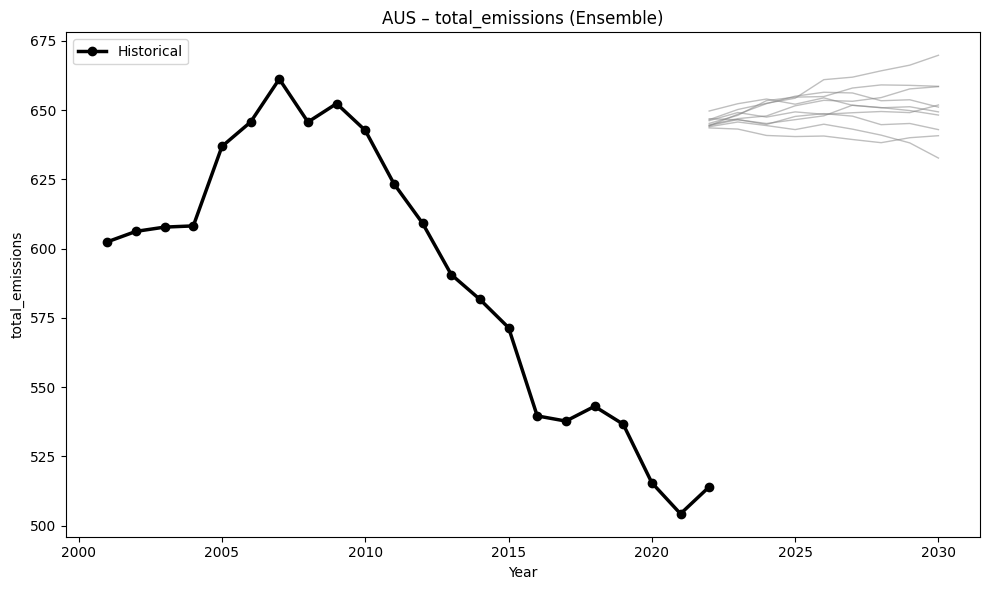

In [54]:
ep.plot_ensemble_time_series(
    df=enet_with_isos_df, 
    iso_alpha_3="AUS",
    column="total_emissions",
    hist_df=training_df_lags)

## Let's calibrate and plot again

In [45]:
xgb_no_isos_df_calibrated = ep.calibrate_total_emissions(
    simulated_df=xgb_no_isos_df,
    initial_emissions_df=initial_conditions_df,
    adjustment_method="additive"
)

enet_with_isos_df_calibrated = ep.calibrate_total_emissions(
    simulated_df=enet_with_isos_df,
    initial_emissions_df=initial_conditions_df,
    adjustment_method="additive"
)

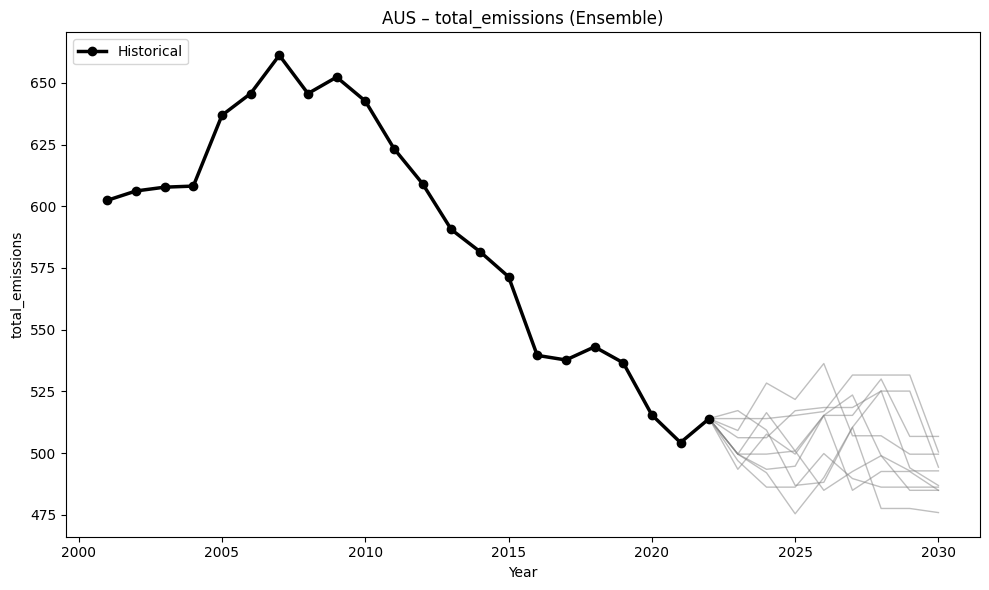

In [55]:
ep.plot_ensemble_time_series(
    df=xgb_no_isos_df_calibrated, 
    iso_alpha_3="AUS",
    column="total_emissions",
    hist_df=training_df_lags)

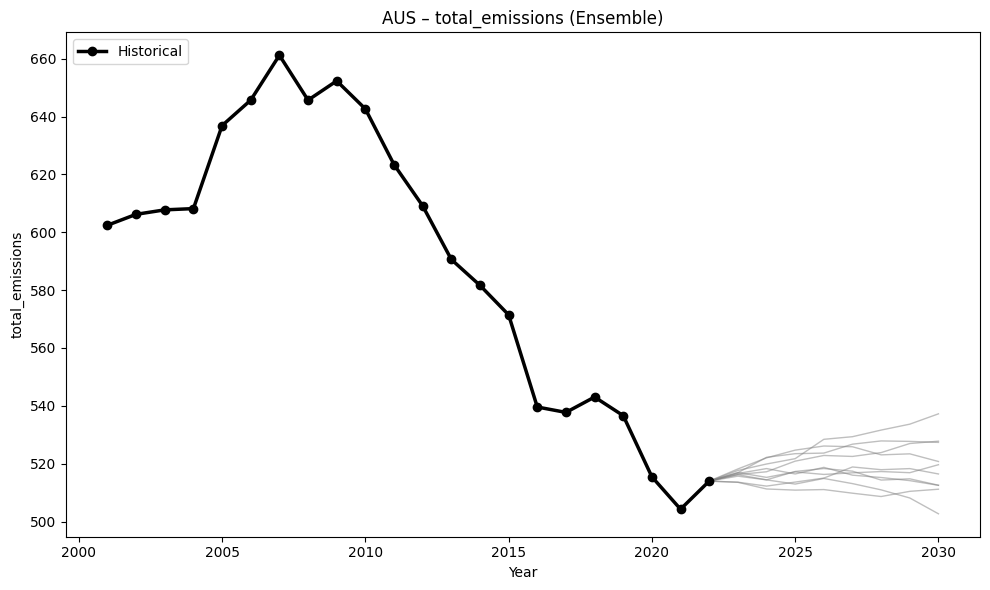

In [56]:
ep.plot_ensemble_time_series(
    df=enet_with_isos_df_calibrated, 
    iso_alpha_3="AUS",
    column="total_emissions",
    hist_df=training_df_lags)